# Optimasi Kombinasi Asupan Makromolekul dengan Linear Programming

Notebook ini digunakan untuk menyusun kombinasi bahan makanan berdasarkan batas minimum dan maksimum karbohidrat, lipid, dan protein. Setiap bahan makanan dinyatakan sebagai variabel keputusan dalam satuan gram, lalu model Linear Programming digunakan untuk mencari kombinasi dengan biaya minimum.

## 1. Import Library

Library yang digunakan mencakup `pandas` dan `numpy` untuk pengolahan data, `scipy.optimize.linprog` untuk menyelesaikan model Linear Programming, serta `matplotlib` untuk visualisasi hasil.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Sumber Data

Nilai makronutrien pada dataset ini merupakan kurasi manual yang disusun berdasarkan rujukan Tabel Komposisi Pangan Indonesia (TKPI). Nilai yang digunakan dibulatkan agar mudah dibaca dan dipakai dalam model komputasi. Rujukan TKPI dapat dilihat melalui repositori publik yang memuat dokumen **Tabel Komposisi Pangan Indonesia**: https://repo.upertis.ac.id/1110/.

Data harga digunakan sebagai pendekatan biaya per 100 gram bahan. Untuk komoditas pangan utama, sumber harga diarahkan pada Panel Harga Pangan Badan Pangan Nasional dan SiPangan Badan Pangan Nasional: https://panelharga.badanpangan.go.id/ dan https://sipangan.badanpangan.go.id/portal/pdi/panel-harga. Beberapa bahan yang tidak muncul secara spesifik pada panel harga diberi catatan sebagai estimasi harga pasar. Dengan demikian, dataset ini lebih tepat disebut sebagai dataset kurasi berbasis sumber tepercaya, bukan data hasil survei langsung.

## 3. Dataset Bahan Pangan

Dataset berisi 20 bahan pangan yang umum ditemukan di Indonesia. Komposisinya dibuat seimbang agar model memiliki pilihan dari kelompok karbohidrat, protein hewani, protein nabati, sayur, buah, dan lipid. Setiap nilai makronutrien dinyatakan per 100 gram bagian pangan yang dapat dimakan.

In [2]:
food_data = [
    {
        "food": "Nasi putih",
        "category": "Karbohidrat",
        "carb_per_100g": 28.00,
        "fat_per_100g": 0.30,
        "protein_per_100g": 2.70,
        "cost_per_100g": 1500,
        "nutrition_source": "TKPI, padanan entri nasi putih",
        "price_source": "Panel Harga Pangan Bapanas, beras nasional",
        "price_note": "Harga pendekatan dari beras yang dikonversi ke porsi 100 g",
    },
    {
        "food": "Kentang rebus",
        "category": "Karbohidrat",
        "carb_per_100g": 20.10,
        "fat_per_100g": 0.10,
        "protein_per_100g": 1.90,
        "cost_per_100g": 1800,
        "nutrition_source": "TKPI, padanan entri kentang rebus",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Tidak semua panel harga menampilkan kentang secara terpisah",
    },
    {
        "food": "Jagung rebus",
        "category": "Karbohidrat",
        "carb_per_100g": 21.00,
        "fat_per_100g": 1.20,
        "protein_per_100g": 3.40,
        "cost_per_100g": 1200,
        "nutrition_source": "TKPI, padanan entri jagung rebus",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga disederhanakan sebagai bahan pangan segar",
    },
    {
        "food": "Ubi jalar",
        "category": "Karbohidrat",
        "carb_per_100g": 20.70,
        "fat_per_100g": 0.30,
        "protein_per_100g": 1.60,
        "cost_per_100g": 1200,
        "nutrition_source": "TKPI, padanan entri ubi jalar",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga disederhanakan untuk simulasi biaya",
    },
    {
        "food": "Roti tawar",
        "category": "Karbohidrat",
        "carb_per_100g": 50.00,
        "fat_per_100g": 3.00,
        "protein_per_100g": 8.00,
        "cost_per_100g": 2000,
        "nutrition_source": "TKPI, padanan entri roti putih",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga produk olahan bervariasi antar merek",
    },
    {
        "food": "Dada ayam",
        "category": "Protein hewani",
        "carb_per_100g": 0.00,
        "fat_per_100g": 3.60,
        "protein_per_100g": 31.00,
        "cost_per_100g": 4500,
        "nutrition_source": "TKPI, padanan entri daging ayam bagian dada",
        "price_source": "Panel Harga Pangan Bapanas, daging ayam ras nasional",
        "price_note": "Harga pendekatan dari komoditas daging ayam",
    },
    {
        "food": "Telur ayam",
        "category": "Protein dan lipid",
        "carb_per_100g": 1.10,
        "fat_per_100g": 10.60,
        "protein_per_100g": 12.60,
        "cost_per_100g": 3000,
        "nutrition_source": "TKPI, padanan entri telur ayam",
        "price_source": "Panel Harga Pangan Bapanas, telur ayam ras nasional",
        "price_note": "Harga dikonversi dari satuan kg ke 100 g",
    },
    {
        "food": "Ikan tuna",
        "category": "Protein hewani",
        "carb_per_100g": 0.00,
        "fat_per_100g": 1.00,
        "protein_per_100g": 29.00,
        "cost_per_100g": 5000,
        "nutrition_source": "TKPI, padanan entri ikan tuna",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga ikan segar berbeda antar wilayah",
    },
    {
        "food": "Ikan kembung",
        "category": "Protein dan lipid",
        "carb_per_100g": 0.00,
        "fat_per_100g": 7.00,
        "protein_per_100g": 22.00,
        "cost_per_100g": 4000,
        "nutrition_source": "TKPI, padanan entri ikan kembung",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga ikan segar berbeda antar wilayah",
    },
    {
        "food": "Daging sapi tanpa lemak",
        "category": "Protein hewani",
        "carb_per_100g": 0.00,
        "fat_per_100g": 8.00,
        "protein_per_100g": 26.00,
        "cost_per_100g": 13500,
        "nutrition_source": "TKPI, padanan entri daging sapi rendah lemak",
        "price_source": "Panel Harga Pangan Bapanas, daging sapi murni nasional",
        "price_note": "Harga pendekatan dari komoditas daging sapi",
    },
    {
        "food": "Tahu",
        "category": "Protein nabati",
        "carb_per_100g": 1.90,
        "fat_per_100g": 4.80,
        "protein_per_100g": 8.10,
        "cost_per_100g": 1500,
        "nutrition_source": "TKPI, padanan entri tahu",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga produk tahu bervariasi menurut ukuran dan daerah",
    },
    {
        "food": "Tempe",
        "category": "Protein nabati",
        "carb_per_100g": 9.40,
        "fat_per_100g": 10.80,
        "protein_per_100g": 20.30,
        "cost_per_100g": 1800,
        "nutrition_source": "TKPI, padanan entri tempe kedelai",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga produk tempe bervariasi menurut ukuran dan daerah",
    },
    {
        "food": "Kacang merah",
        "category": "Protein nabati dan karbohidrat",
        "carb_per_100g": 22.80,
        "fat_per_100g": 0.50,
        "protein_per_100g": 10.30,
        "cost_per_100g": 3500,
        "nutrition_source": "TKPI, padanan entri kacang merah",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga kacang kering bervariasi menurut kualitas",
    },
    {
        "food": "Bayam",
        "category": "Sayur",
        "carb_per_100g": 3.60,
        "fat_per_100g": 0.40,
        "protein_per_100g": 2.90,
        "cost_per_100g": 1200,
        "nutrition_source": "TKPI, padanan entri bayam",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga sayur bervariasi dan umumnya tidak seragam di panel nasional",
    },
    {
        "food": "Kangkung",
        "category": "Sayur",
        "carb_per_100g": 3.90,
        "fat_per_100g": 0.30,
        "protein_per_100g": 3.00,
        "cost_per_100g": 1000,
        "nutrition_source": "TKPI, padanan entri kangkung",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga sayur bervariasi dan umumnya tidak seragam di panel nasional",
    },
    {
        "food": "Wortel",
        "category": "Sayur",
        "carb_per_100g": 9.60,
        "fat_per_100g": 0.20,
        "protein_per_100g": 0.90,
        "cost_per_100g": 1500,
        "nutrition_source": "TKPI, padanan entri wortel",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga sayur bervariasi dan umumnya tidak seragam di panel nasional",
    },
    {
        "food": "Brokoli",
        "category": "Sayur",
        "carb_per_100g": 6.60,
        "fat_per_100g": 0.40,
        "protein_per_100g": 2.80,
        "cost_per_100g": 4000,
        "nutrition_source": "TKPI atau rujukan komposisi pangan padanan brokoli",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga brokoli bervariasi dan sering lebih tinggi dari sayur lokal lain",
    },
    {
        "food": "Pisang",
        "category": "Buah",
        "carb_per_100g": 23.00,
        "fat_per_100g": 0.30,
        "protein_per_100g": 1.10,
        "cost_per_100g": 1800,
        "nutrition_source": "TKPI, padanan entri pisang",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga buah bervariasi menurut jenis pisang dan daerah",
    },
    {
        "food": "Alpukat",
        "category": "Lipid nabati",
        "carb_per_100g": 8.50,
        "fat_per_100g": 14.70,
        "protein_per_100g": 2.00,
        "cost_per_100g": 3500,
        "nutrition_source": "TKPI, padanan entri alpukat",
        "price_source": "Estimasi harga pasar nasional",
        "price_note": "Harga buah bervariasi menurut musim dan daerah",
    },
    {
        "food": "Minyak kelapa sawit",
        "category": "Lipid",
        "carb_per_100g": 0.00,
        "fat_per_100g": 100.00,
        "protein_per_100g": 0.00,
        "cost_per_100g": 2200,
        "nutrition_source": "TKPI, padanan entri minyak kelapa sawit",
        "price_source": "Panel Harga Pangan Bapanas, minyak goreng nasional",
        "price_note": "Harga dikonversi dari harga minyak goreng ke pendekatan 100 g",
    },
]

food_df = pd.DataFrame(food_data)
display(food_df)

,food,category,carb_per_100g,fat_per_100g,protein_per_100g,cost_per_100g,nutrition_source,price_source,price_note
0,Nasi putih,Karbohidrat,28.00,0.30,2.70,1500,"TKPI, padanan entri nasi putih","Panel Harga Pangan Bapanas, beras nasional",Harga pendekatan dari beras yang dikonversi ke...
1,Kentang rebus,Karbohidrat,20.10,0.10,1.90,1800,"TKPI, padanan entri kentang rebus",Estimasi harga pasar nasional,Tidak semua panel harga menampilkan kentang se...
2,Jagung rebus,Karbohidrat,21.00,1.20,3.40,1200,"TKPI, padanan entri jagung rebus",Estimasi harga pasar nasional,Harga disederhanakan sebagai bahan pangan segar
3,Ubi jalar,Karbohidrat,20.70,0.30,1.60,1200,"TKPI, padanan entri ubi jalar",Estimasi harga pasar nasional,Harga disederhanakan untuk simulasi biaya
4,Roti tawar,Karbohidrat,50.00,3.00,8.00,2000,"TKPI, padanan entri roti putih",Estimasi harga pasar nasional,Harga produk olahan bervariasi antar merek
5,Dada ayam,Protein hewani,0.00,3.60,31.00,4500,"TKPI, padanan entri daging ayam bagian dada","Panel Harga Pangan Bapanas, daging ayam ras na...",Harga pendekatan dari komoditas daging ayam
6,Telur ayam,Protein dan lipid,1.10,10.60,12.60,3000,"TKPI, padanan entri telur ayam","Panel Harga Pangan Bapanas, telur ayam ras nas...",Harga dikonversi dari satuan kg ke 100 g
7,Ikan tuna,Protein hewani,0.00,1.00,29.00,5000,"TKPI, padanan entri ikan tuna",Estimasi harga pasar nasional,Harga ikan segar berbeda antar wilayah
8,Ikan kembung,Protein dan lipid,0.00,7.00,22.00,4000,"TKPI, padanan entri ikan kembung",Estimasi harga pasar nasional,Harga ikan segar berbeda antar wilayah
9,Daging sapi tanpa lemak,Protein hewani,0.00,8.00,26.00,13500,"TKPI, padanan entri daging sapi rendah lemak","Panel Harga Pangan Bapanas, daging sapi murni ...",Harga pendekatan dari komoditas daging sapi


## 4. Pra-pemrosesan Data

Nilai pada dataset masih berada dalam satuan per 100 gram. Agar dapat digunakan pada variabel keputusan `x_i` yang merepresentasikan berat bahan dalam gram, nilai tersebut dikonversi ke satuan per gram. Pada bagian ini juga dihitung estimasi kalori per 100 gram berdasarkan faktor energi umum, yaitu 4 kkal per gram karbohidrat, 9 kkal per gram lipid, dan 4 kkal per gram protein.

In [3]:
processed_df = food_df.copy()
processed_df["carb_per_g"] = processed_df["carb_per_100g"] / 100
processed_df["fat_per_g"] = processed_df["fat_per_100g"] / 100
processed_df["protein_per_g"] = processed_df["protein_per_100g"] / 100
processed_df["cost_per_g"] = processed_df["cost_per_100g"] / 100
processed_df["calorie_per_100g"] = (
    4 * processed_df["carb_per_100g"]
    + 9 * processed_df["fat_per_100g"]
    + 4 * processed_df["protein_per_100g"]
)

display(processed_df[[
    "food", "category", "carb_per_100g", "fat_per_100g",
    "protein_per_100g", "cost_per_100g", "calorie_per_100g"
]])

,food,category,carb_per_100g,fat_per_100g,protein_per_100g,cost_per_100g,calorie_per_100g
0,Nasi putih,Karbohidrat,28.00,0.30,2.70,1500,125.50
1,Kentang rebus,Karbohidrat,20.10,0.10,1.90,1800,88.90
2,Jagung rebus,Karbohidrat,21.00,1.20,3.40,1200,108.40
3,Ubi jalar,Karbohidrat,20.70,0.30,1.60,1200,91.90
4,Roti tawar,Karbohidrat,50.00,3.00,8.00,2000,259.00
5,Dada ayam,Protein hewani,0.00,3.60,31.00,4500,156.40
6,Telur ayam,Protein dan lipid,1.10,10.60,12.60,3000,150.20
7,Ikan tuna,Protein hewani,0.00,1.00,29.00,5000,125.00
8,Ikan kembung,Protein dan lipid,0.00,7.00,22.00,4000,151.00
9,Daging sapi tanpa lemak,Protein hewani,0.00,8.00,26.00,13500,176.00


## 5. Fungsi Optimasi Linear Programming

Model menggunakan berat setiap bahan makanan sebagai variabel keputusan. Fungsi tujuan utama adalah meminimalkan biaya total, sedangkan kendala memastikan total karbohidrat, lipid, dan protein tetap berada pada rentang yang ditentukan. Batas porsi tiap bahan ditetapkan 300 gram agar solusi tidak terlalu bergantung pada satu bahan saja.

In [4]:
def solve_macro_lp(food_df, targets, objective="cost", max_serving=300):
    nutrient_matrix = food_df[["carb_per_g", "fat_per_g", "protein_per_g"]].to_numpy()

    if objective == "cost":
        c = food_df["cost_per_g"].to_numpy()
    elif objective == "fat":
        c = food_df["fat_per_g"].to_numpy()
    else:
        raise ValueError("objective hanya mendukung nilai 'cost' atau 'fat'")

    carb = nutrient_matrix[:, 0]
    fat = nutrient_matrix[:, 1]
    protein = nutrient_matrix[:, 2]

    # Kendala batas atas dan bawah makronutrien.
    A_ub = np.vstack([
        carb,
        -carb,
        fat,
        -fat,
        protein,
        -protein,
    ])
    b_ub = np.array([
        targets["carb_max"],
        -targets["carb_min"],
        targets["fat_max"],
        -targets["fat_min"],
        targets["protein_max"],
        -targets["protein_min"],
    ])

    bounds = [(0, max_serving) for _ in range(len(food_df))]

    return linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs",
    )

## 6. Fungsi Ringkasan dan Visualisasi

Fungsi berikut digunakan untuk mengubah hasil optimasi menjadi tabel yang mudah dibaca. Selain tabel berat bahan makanan, notebook juga menampilkan ringkasan total makronutrien, total kalori, total biaya, pie chart komposisi kalori, dan bar chart berat bahan makanan yang dipilih.

In [5]:
def summarize_solution(food_df, solution):
    result_df = food_df[["food", "category"]].copy()
    result_df["weight_g"] = solution.x
    result_df["carb_g"] = result_df["weight_g"] * food_df["carb_per_g"]
    result_df["fat_g"] = result_df["weight_g"] * food_df["fat_per_g"]
    result_df["protein_g"] = result_df["weight_g"] * food_df["protein_per_g"]
    result_df["calorie_kcal"] = 4 * result_df["carb_g"] + 9 * result_df["fat_g"] + 4 * result_df["protein_g"]
    result_df["cost_rupiah"] = result_df["weight_g"] * food_df["cost_per_g"]

    selected_df = result_df[result_df["weight_g"] > 1].copy()
    selected_df = selected_df.sort_values("weight_g", ascending=False)

    totals = {
        "total_carb_g": result_df["carb_g"].sum(),
        "total_fat_g": result_df["fat_g"].sum(),
        "total_protein_g": result_df["protein_g"].sum(),
        "total_calorie_kcal": result_df["calorie_kcal"].sum(),
        "total_cost_rupiah": result_df["cost_rupiah"].sum(),
    }

    return selected_df, pd.DataFrame([totals])


def plot_calorie_pie(totals_df, title):
    totals = totals_df.iloc[0]
    calorie_values = [
        4 * totals["total_carb_g"],
        9 * totals["total_fat_g"],
        4 * totals["total_protein_g"],
    ]
    labels = ["Karbohidrat", "Lipid", "Protein"]

    plt.figure(figsize=(5.5, 5.5))
    plt.pie(calorie_values, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title(title)
    plt.show()


def plot_food_weights(selected_df, title):
    plt.figure(figsize=(9, 4.5))
    plt.bar(selected_df["food"], selected_df["weight_g"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Berat bahan (g)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 7. Skenario Bawaan

Empat skenario berikut digunakan untuk menguji model. Tiga skenario pertama menggambarkan target yang masih mungkin dicari solusinya, sedangkan skenario terakhir sengaja dibuat ketat untuk menunjukkan bagaimana program menangani kondisi tidak feasible.

In [6]:
scenarios = {
    "Skenario Seimbang": {
        "carb_min": 80,
        "carb_max": 120,
        "fat_min": 20,
        "fat_max": 40,
        "protein_min": 40,
        "protein_max": 70,
    },
    "Skenario Rendah Karbohidrat": {
        "carb_min": 30,
        "carb_max": 60,
        "fat_min": 20,
        "fat_max": 50,
        "protein_min": 50,
        "protein_max": 80,
    },
    "Skenario Pembatasan Protein": {
        "carb_min": 90,
        "carb_max": 140,
        "fat_min": 20,
        "fat_max": 45,
        "protein_min": 20,
        "protein_max": 40,
    },
    "Skenario Tidak Feasible": {
        "carb_min": 200,
        "carb_max": 220,
        "fat_min": 0,
        "fat_max": 1,
        "protein_min": 100,
        "protein_max": 120,
    },
}

pd.DataFrame(scenarios).T

,carb_min,carb_max,fat_min,fat_max,protein_min,protein_max
Skenario Seimbang,80,120,20,40,40,70
Skenario Rendah Karbohidrat,30,60,20,50,50,80
Skenario Pembatasan Protein,90,140,20,45,20,40
Skenario Tidak Feasible,200,220,0,1,100,120


## 8. Eksekusi Optimasi dan Analisis Hasil

Bagian ini menjalankan seluruh skenario secara otomatis. Jika solusi ditemukan, hasil ditampilkan dalam bentuk tabel dan grafik. Jika solusi tidak ditemukan, notebook menampilkan keterangan bahwa batas target terlalu ketat terhadap dataset dan batas porsi yang digunakan.

### Skenario Seimbang

Target skenario: Karbohidrat 80 sampai 120 g, lipid 20 sampai 40 g, dan protein 40 sampai 70 g.

**Tabel bahan makanan terpilih**

,food,category,weight_g,carb_g,fat_g,protein_g,calorie_kcal,cost_rupiah
11,Tempe,Protein nabati,144.71,13.60,15.63,29.38,312.58,2604.81
4,Roti tawar,Karbohidrat,132.79,66.40,3.98,10.62,343.94,2655.88


**Ringkasan total**

,total_carb_g,total_fat_g,total_protein_g,total_calorie_kcal,total_cost_rupiah
0,80.00,20.00,40.00,660.00,5269.21


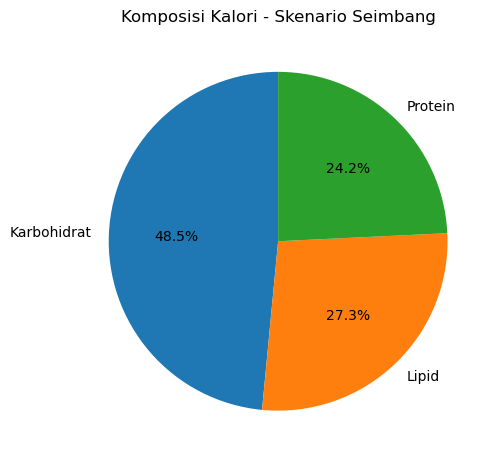

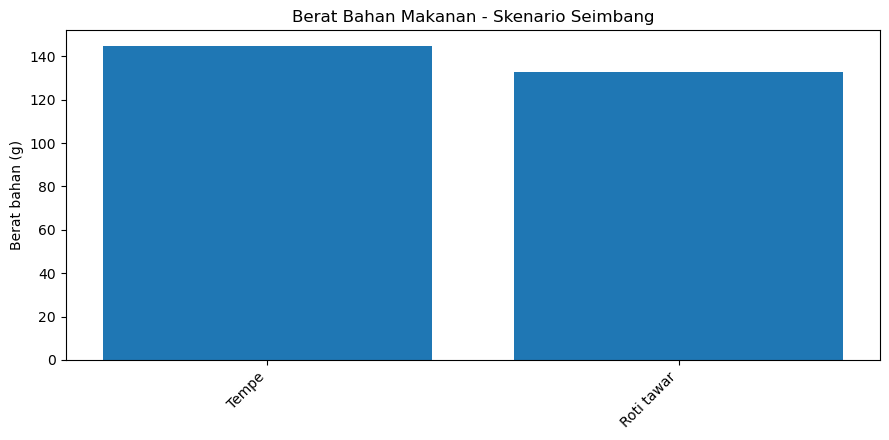

Berdasarkan hasil optimasi, skenario seimbang menghasilkan total karbohidrat 80.00 g, lipid 20.00 g, dan protein 40.00 g. Nilai tersebut berada dalam rentang target yang ditentukan, yaitu Karbohidrat 80 sampai 120 g, lipid 20 sampai 40 g, dan protein 40 sampai 70 g. Total energi menu adalah 660.00 kkal dengan perkiraan biaya Rp5269. Hasil ini menunjukkan bahwa model dapat memilih kombinasi bahan pangan yang memenuhi batas makronutrien sambil menjaga biaya tetap minimum berdasarkan dataset yang digunakan.

### Skenario Rendah Karbohidrat

Target skenario: Karbohidrat 30 sampai 60 g, lipid 20 sampai 50 g, dan protein 50 sampai 80 g.

**Tabel bahan makanan terpilih**

,food,category,weight_g,carb_g,fat_g,protein_g,calorie_kcal,cost_rupiah
11,Tempe,Protein nabati,240.48,22.60,25.97,48.82,519.43,4328.58
4,Roti tawar,Karbohidrat,14.79,7.40,0.44,1.18,38.31,295.81


**Ringkasan total**

,total_carb_g,total_fat_g,total_protein_g,total_calorie_kcal,total_cost_rupiah
0,30.00,26.42,50.00,557.74,4624.39


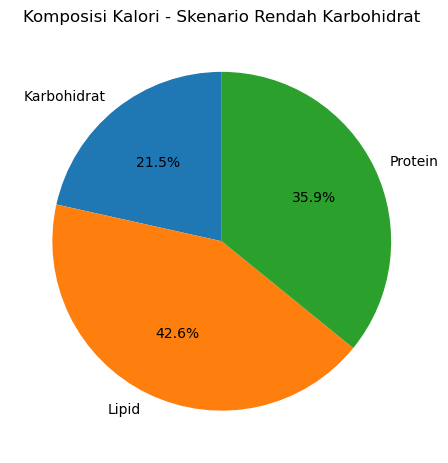

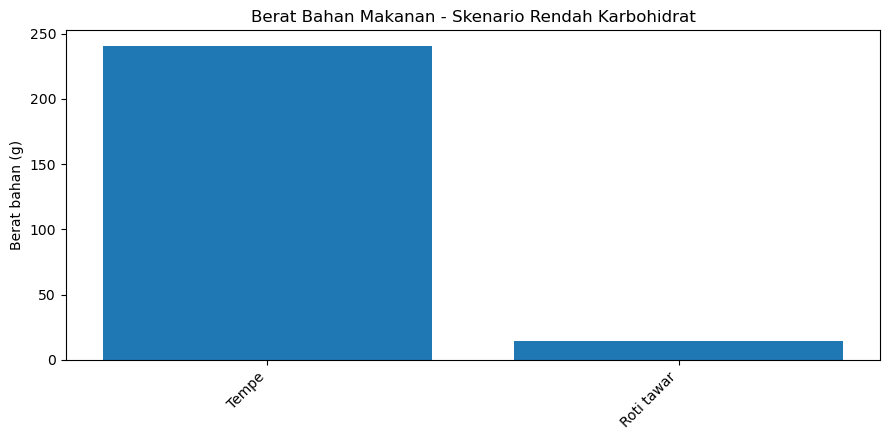

Berdasarkan hasil optimasi, skenario rendah karbohidrat menghasilkan total karbohidrat 30.00 g, lipid 26.42 g, dan protein 50.00 g. Nilai tersebut berada dalam rentang target yang ditentukan, yaitu Karbohidrat 30 sampai 60 g, lipid 20 sampai 50 g, dan protein 50 sampai 80 g. Total energi menu adalah 557.74 kkal dengan perkiraan biaya Rp4624. Hasil ini menunjukkan bahwa model dapat memilih kombinasi bahan pangan yang memenuhi batas makronutrien sambil menjaga biaya tetap minimum berdasarkan dataset yang digunakan.

### Skenario Pembatasan Protein

Target skenario: Karbohidrat 90 sampai 140 g, lipid 20 sampai 45 g, dan protein 20 sampai 40 g.

**Tabel bahan makanan terpilih**

,food,category,weight_g,carb_g,fat_g,protein_g,calorie_kcal,cost_rupiah
4,Roti tawar,Karbohidrat,174.40,87.20,5.23,13.95,451.69,3487.98
11,Tempe,Protein nabati,29.79,2.80,3.22,6.05,64.35,536.28
19,Minyak kelapa sawit,Lipid,11.55,0.00,11.55,0.00,103.95,254.11


**Ringkasan total**

,total_carb_g,total_fat_g,total_protein_g,total_calorie_kcal,total_cost_rupiah
0,90.00,20.00,20.00,620.00,4278.37


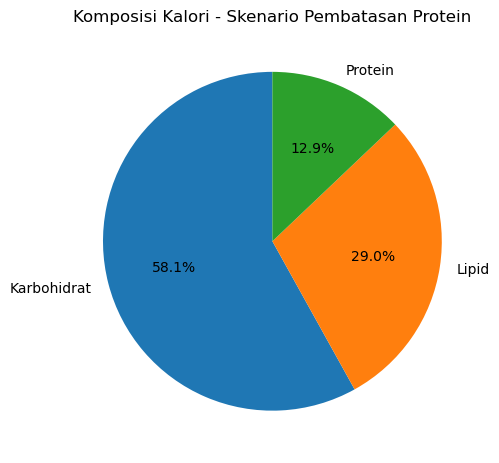

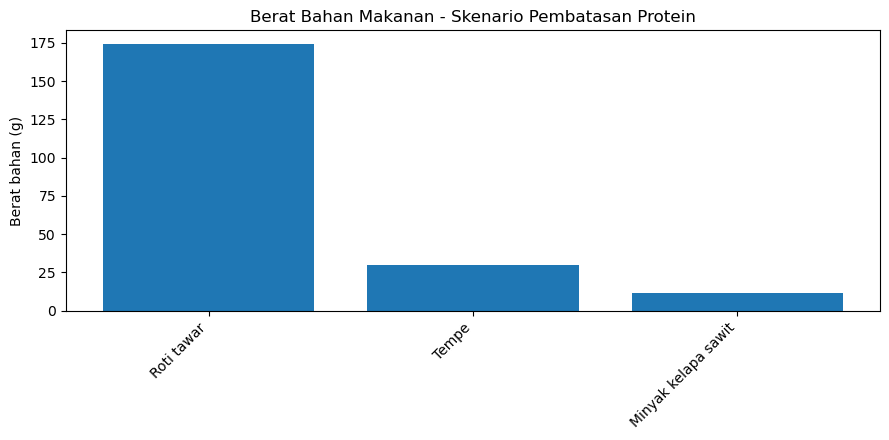

Berdasarkan hasil optimasi, skenario pembatasan protein menghasilkan total karbohidrat 90.00 g, lipid 20.00 g, dan protein 20.00 g. Nilai tersebut berada dalam rentang target yang ditentukan, yaitu Karbohidrat 90 sampai 140 g, lipid 20 sampai 45 g, dan protein 20 sampai 40 g. Total energi menu adalah 620.00 kkal dengan perkiraan biaya Rp4278. Hasil ini menunjukkan bahwa model dapat memilih kombinasi bahan pangan yang memenuhi batas makronutrien sambil menjaga biaya tetap minimum berdasarkan dataset yang digunakan.

### Skenario Tidak Feasible

Target skenario: Karbohidrat 200 sampai 220 g, lipid 0 sampai 1 g, dan protein 100 sampai 120 g.

Solusi tidak ditemukan. Target pada skenario ini terlalu ketat untuk dataset dan batas porsi yang digunakan, sehingga model Linear Programming mengembalikan status tidak feasible.

The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)


In [7]:
def format_target_text(targets):
    return (
        f"Karbohidrat {targets['carb_min']} sampai {targets['carb_max']} g, "
        f"lipid {targets['fat_min']} sampai {targets['fat_max']} g, "
        f"dan protein {targets['protein_min']} sampai {targets['protein_max']} g."
    )


def display_result_analysis(name, targets, totals_df):
    totals = totals_df.iloc[0]
    text = (
        f"Berdasarkan hasil optimasi, {name.lower()} menghasilkan total karbohidrat "
        f"{totals['total_carb_g']:.2f} g, lipid {totals['total_fat_g']:.2f} g, "
        f"dan protein {totals['total_protein_g']:.2f} g. Nilai tersebut berada dalam "
        f"rentang target yang ditentukan, yaitu {format_target_text(targets)} "
        f"Total energi menu adalah {totals['total_calorie_kcal']:.2f} kkal dengan "
        f"perkiraan biaya Rp{totals['total_cost_rupiah']:.0f}. Hasil ini menunjukkan "
        f"bahwa model dapat memilih kombinasi bahan pangan yang memenuhi batas "
        f"makronutrien sambil menjaga biaya tetap minimum berdasarkan dataset yang digunakan."
    )
    display(Markdown(text))


def run_scenario(name, targets, food_df):
    display(Markdown(f"### {name}"))
    display(Markdown(f"Target skenario: {format_target_text(targets)}"))

    solution = solve_macro_lp(food_df, targets, objective="cost", max_serving=300)

    # Status solusi perlu dicek sebelum hasil diolah lebih lanjut.
    if not solution.success:
        display(Markdown(
            "Solusi tidak ditemukan. Target pada skenario ini terlalu ketat untuk "
            "dataset dan batas porsi yang digunakan, sehingga model Linear Programming "
            "mengembalikan status tidak feasible."
        ))
        print(solution.message)
        return None

    selected_df, totals_df = summarize_solution(food_df, solution)

    display(Markdown("**Tabel bahan makanan terpilih**"))
    display(selected_df[[
        "food", "category", "weight_g", "carb_g", "fat_g",
        "protein_g", "calorie_kcal", "cost_rupiah"
    ]])

    display(Markdown("**Ringkasan total**"))
    display(totals_df)

    plot_calorie_pie(totals_df, f"Komposisi Kalori - {name}")
    plot_food_weights(selected_df, f"Berat Bahan Makanan - {name}")
    display_result_analysis(name, targets, totals_df)

    return selected_df, totals_df

scenario_results = {}
for scenario_name, target_values in scenarios.items():
    scenario_results[scenario_name] = run_scenario(scenario_name, target_values, processed_df)

## 9. Ringkasan Perbandingan Skenario

Tabel berikut merangkum hasil utama dari setiap skenario yang memiliki solusi. Ringkasan ini membantu melihat perubahan biaya, energi, dan total makronutrien ketika batas target diubah.

In [8]:
comparison_rows = []
for scenario_name, result in scenario_results.items():
    if result is None:
        comparison_rows.append({
            "scenario": scenario_name,
            "status": "Tidak feasible",
            "total_carb_g": np.nan,
            "total_fat_g": np.nan,
            "total_protein_g": np.nan,
            "total_calorie_kcal": np.nan,
            "total_cost_rupiah": np.nan,
        })
    else:
        _, totals_df = result
        totals = totals_df.iloc[0].to_dict()
        comparison_rows.append({"scenario": scenario_name, "status": "Feasible", **totals})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,scenario,status,total_carb_g,total_fat_g,total_protein_g,total_calorie_kcal,total_cost_rupiah
0,Skenario Seimbang,Feasible,80.00,20.00,40.00,660.00,5269.21
1,Skenario Rendah Karbohidrat,Feasible,30.00,26.42,50.00,557.74,4624.39
2,Skenario Pembatasan Protein,Feasible,90.00,20.00,20.00,620.00,4278.37
3,Skenario Tidak Feasible,Tidak feasible,NaN,NaN,NaN,NaN,NaN


## 10. Kesimpulan

Berdasarkan pengujian skenario, Linear Programming dapat digunakan untuk menyusun kombinasi bahan pangan yang memenuhi batas karbohidrat, lipid, dan protein selama target yang diberikan masih sesuai dengan pilihan bahan dan batas porsi. Skenario yang feasible menghasilkan tabel berat bahan makanan beserta total makronutrien, kalori, dan biaya. Sementara itu, skenario tidak feasible menunjukkan bahwa model juga dapat membantu mendeteksi target yang terlalu sempit atau tidak realistis terhadap dataset yang tersedia.

Keterbatasan utama notebook ini adalah dataset masih berupa kurasi manual dan hanya mempertimbangkan tiga makronutrien utama. Faktor lain seperti serat, natrium, kalium, indeks glikemik, alergi, preferensi rasa, serta cara pengolahan belum dimasukkan. Oleh karena itu, hasil notebook lebih tepat digunakan sebagai demonstrasi komputasi biologi, bukan sebagai panduan diet klinis yang langsung diterapkan.